In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as stats

In [3]:
#get data
jordan = pd.read_csv('data/jordan-river.csv')
bear = pd.read_csv('data/bear-river.csv')
weber = pd.read_csv('data/weber-river.csv')

cols_to_drop = [
    'x', 'y', 'id', 'time_series_id', 'monitoring_location_id',
    'parameter_code', 'statistic_id',
    'approval_status', 'qualifier', 'last_modified'
]

for river in [jordan, bear, weber]:
    river['time'] = pd.to_datetime(river['time'])
    river.drop(cols_to_drop, axis=1, inplace=True)
    river.sort_values('time', inplace=True)
    river['days'] = (river['time'] - river['time'].min()).dt.days
#combine
df = jordan.merge(bear, on="time", how="outer")
df = df.merge(weber, on="time", how="outer")
df['value'] = df['value'] + df['value_x'] + df['value_y']
df['value'] = df['value'] * 0.0283168 #conversion to cubic meters
print(df.head())
df.drop(['unit_of_measure_x', 'unit_of_measure_y', 'value_x', 'value_y', 'days_x', 'days_y'], axis=1, inplace=True)
df.drop('unit_of_measure', axis=1, inplace=True)

        time  value_x unit_of_measure_x  days_x  value_y unit_of_measure_y  \
0 1998-10-24    144.0            ft^3/s       0   2080.0            ft^3/s   
1 1998-10-25    143.0            ft^3/s       1   2090.0            ft^3/s   
2 1998-10-26    156.0            ft^3/s       2   2590.0            ft^3/s   
3 1998-10-27    165.0            ft^3/s       3   2270.0            ft^3/s   
4 1998-10-28    161.0            ft^3/s       4   2430.0            ft^3/s   

   days_y      value unit_of_measure  days  
0       0  73.567046          ft^3/s     0  
1       1  74.076749          ft^3/s     1  
2       2  88.744851          ft^3/s     2  
3       3  79.768426          ft^3/s     3  
4       4  83.194758          ft^3/s     4  


In [4]:
df.to_csv("data/historical_river_inflow.csv")

In [5]:
#fit sinusoidal wave
x = df["days"].to_numpy()
y = df["value"].to_numpy()

def sinusoid(t, A, B, phi, C):
    return A * np.sin(B * t + phi) + C

A0 = (y.max() - y.min()) / 2
B0 = 2 * np.pi / 365.25
phi0 = 0
C0 = y.mean()

params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
A_fit, B_fit, phi_fit, C_fit = params

df["fit"] = sinusoid(df["days"], A_fit, B_fit, phi_fit, C_fit)



In [6]:
df.head()

,time,value,days,fit
0,1998-10-24,73.567046,0,20.391395
1,1998-10-25,74.076749,1,20.640754
2,1998-10-26,88.744851,2,20.897452
3,1998-10-27,79.768426,3,21.161411
4,1998-10-28,83.194758,4,21.432555


In [7]:
#fit attempt 2
def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
    omega = 2 * np.pi / 365
    return (
        A1 * np.sin(omega * t + phi1)
        + A2 * np.sin(2 * omega * t + phi2)
        + C
    )

p0 = [
    (y.max() - y.min()) / 2, 0,
    (y.max() - y.min()) / 4, 0,
    y.mean()
]

params2, _ = curve_fit(seasonal_two_harmonics, x, y)
print(params2)
df["fit2"] = seasonal_two_harmonics(df["days"], *params2)

[-28.97393599 -23.20200893 -18.43745938   4.2925041   45.52330359]


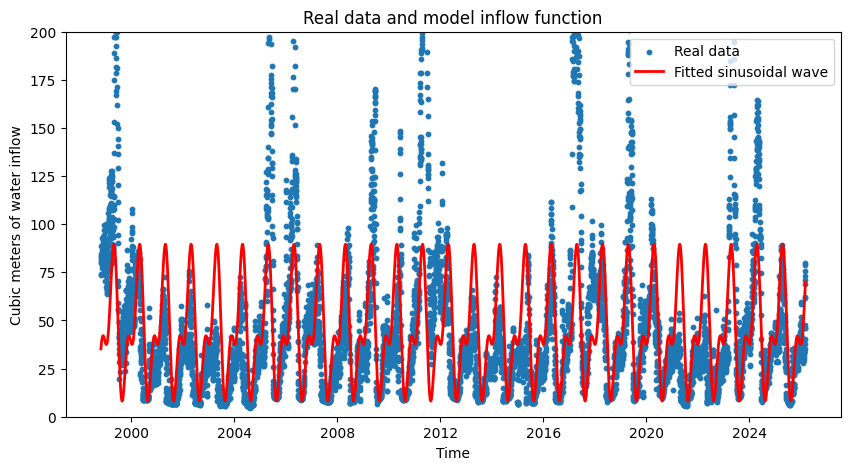

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], df["fit2"], linewidth=2, label="Fitted sinusoidal wave", c='r')
plt.title(r"Real data and model inflow function")
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.ylim(0, 200)
plt.savefig('images/basic_inflow_1.png')
plt.show()

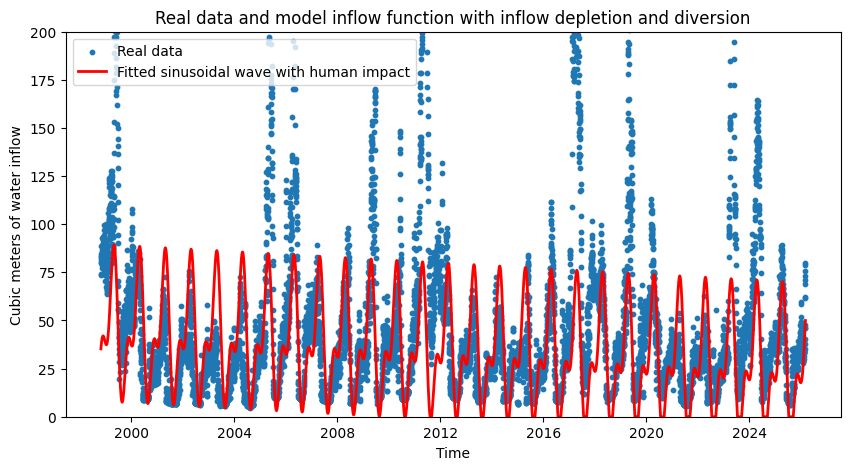

In [9]:
#to account for human impact, add a negative linear trend
seasonal_two_harmonics_human = lambda t, A1, phi1, A2, phi2, C, nu: (
    A1 * np.sin(2 * np.pi / 365 * t + phi1)
    + A2 * np.sin(2 * 2 * np.pi / 365 * t + phi2)
    + C
)   - (nu * t)

df['fit3'] = seasonal_two_harmonics_human(df["days"], *params2,  0.002)
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], np.maximum(df["fit3"], 0), linewidth=2, label="Fitted sinusoidal wave with human impact", c='r')
plt.title(r"Real data and model inflow function with inflow depletion and diversion")
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.savefig('images/inflow_with_depletion.png')
plt.show()

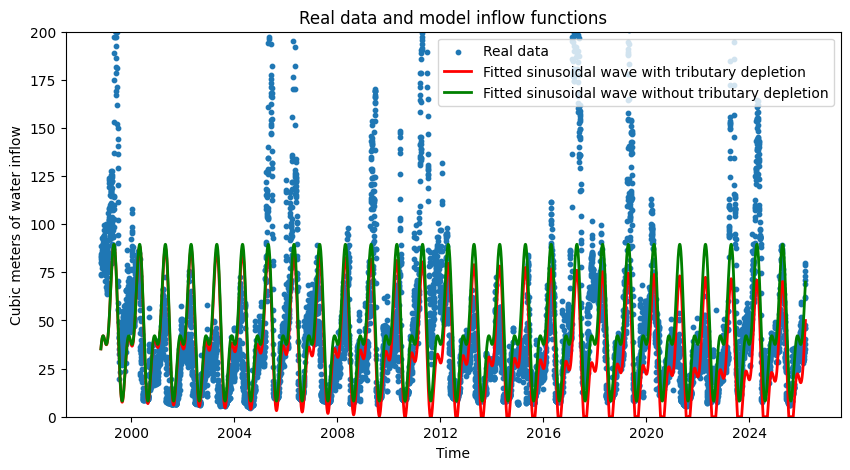

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], np.maximum(df["fit3"], 0), linewidth=2, label="Fitted sinusoidal wave with tributary depletion", c='r')
plt.plot(df["time"], df["fit2"], linewidth=2, label="Fitted sinusoidal wave without tributary depletion", c='green')
plt.title(r"Real data and model inflow functions")
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.savefig('images/inflow.png')
plt.show()

In [143]:
df_2000 = df[df["time"] >= "2000-01-01"].copy()
len(df_2000)

9566

In [144]:
df_2000.set_index(np.arange(9566), inplace=True)

In [145]:
df_2000["day"] = np.mod(np.arange(9566), 365)

In [146]:
days_dict = {}
vars = df_2000[["value", "day"]].groupby("day").var().values
means = df_2000[["value", "day"]].groupby("day").mean().values
for i in range(365):
    days_dict[i] = {"mean": means[i][0], "var": vars[i][0]}
sim_df = pd.DataFrame(days_dict).T

135


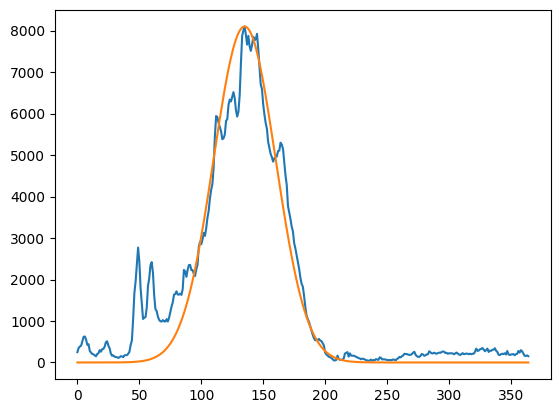

In [299]:
plt.plot(sim_df["var"])
print(np.argmax(sim_df["var"]))
domain = np.arange(365)
pdf_vals = stats.norm.pdf(domain, 125, 25)
scale = np.max(sim_df["var"]) / np.max(pdf_vals)
plt.plot(domain, scale*stats.norm.pdf(domain, 135, 25))

In [281]:
df_2000["year"] = 0
for i in range(len(df_2000)):
    df_2000.at[i, "year"] = int(str(df_2000.iloc[i]["time"]).split("-")[0])
df_2000

,time,value,day,year,spring mean,adj value,error,SE,pred
0,2000-01-01,92.397718,0,2000,66.430102,1.390901,-48.757844,2233.353304,43.639874
1,2000-01-02,105.621664,1,2000,66.430102,1.589967,-62.070224,3667.003538,43.551440
2,2000-01-03,96.418704,2,2000,66.430102,1.451431,-54.837411,2832.613957,41.581293
3,2000-01-04,86.706042,3,2000,66.430102,1.305222,-45.720824,1957.094374,40.985218
4,2000-01-05,83.619510,4,2000,66.430102,1.258759,-41.006903,1537.689693,42.612607
...,...,...,...,...,...,...,...,...,...
9492,2025-12-27,43.975990,2,2025,68.921481,0.638059,-0.835242,1.756753,43.140748
9493,2025-12-28,41.229261,3,2025,68.921481,0.598206,1.293057,0.491550,42.522318
9494,2025-12-29,43.437971,4,2025,68.921481,0.630253,0.772769,0.165677,44.210740
9495,2025-12-30,47.543907,5,2025,68.921481,0.689827,-2.577758,9.453792,44.966149


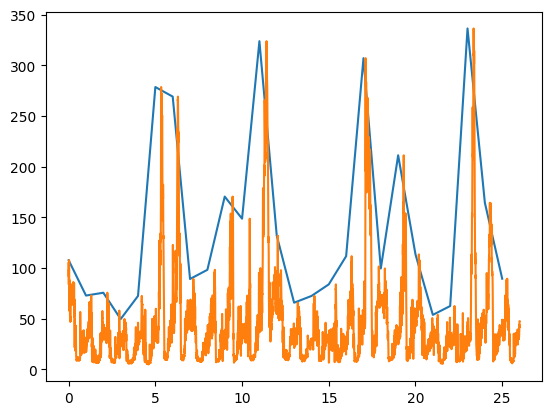

In [282]:
maxes = df_2000[["value", "year"]].groupby("year").max()["value"].values
plt.plot(np.arange(26), maxes)
plt.plot(np.linspace(0, 26, 9497), df_2000["value"])

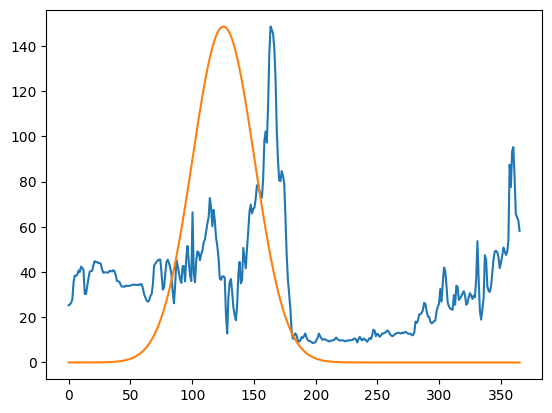

In [309]:
scales = maxes / np.max(pdf_vals)
n = 10
plt.plot(np.linspace(0, 365, 365), df_2000["value"][365*n:365*(n+1)])
plt.plot(np.linspace(0, 365, 365), scales[n]*pdf_vals)

(array([14.,  5.,  3.,  2.,  3.]),
 array([ 49.6110336 , 106.94184985, 164.2726661 , 221.60348235,
        278.9342986 , 336.26511485]),
 <BarContainer object of 5 artists>)

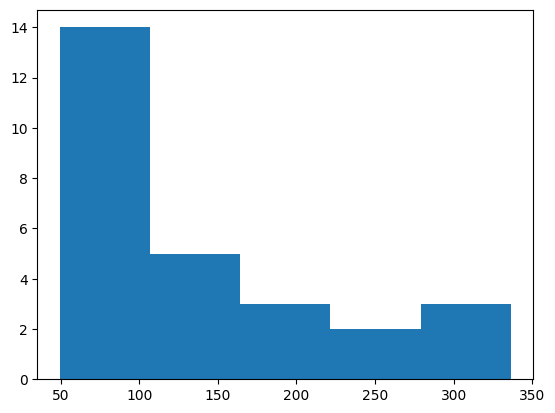

In [68]:
plt.hist(maxes, bins='fd')

138.4461944165926 7903.0910720871425
4.759740013490972 0.3315133358925802


(array([4., 8., 5., 4., 1., 5.]),
 array([3.90421326, 4.22316103, 4.5421088 , 4.86105657, 5.18000434,
        5.49895211, 5.81789988]),
 <BarContainer object of 6 artists>)

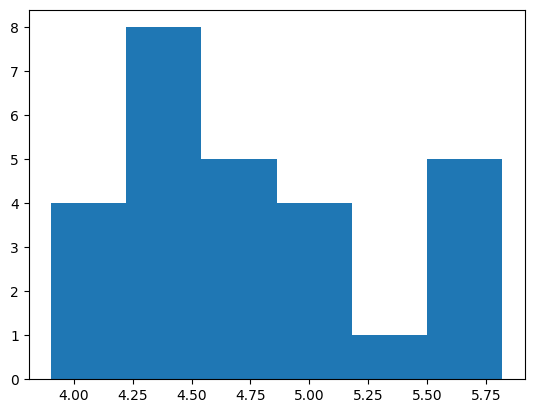

In [73]:
print(np.mean(maxes), np.var(maxes, ddof=1))
log_maxes = np.log(maxes)
print(np.mean(log_maxes), np.var(log_maxes, ddof=1))
plt.hist(log_maxes, bins=6)

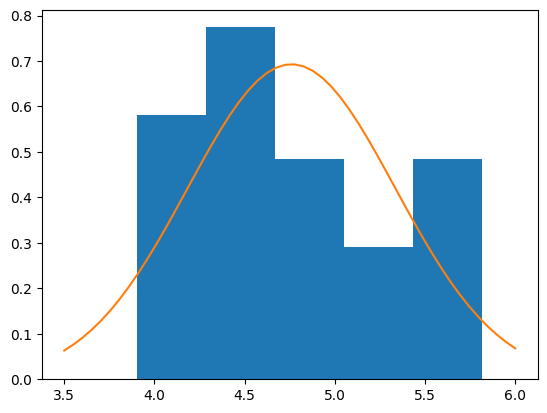

In [79]:
domain = np.linspace(3.5, 6)
pdf_vals = stats.norm.pdf(domain, 4.759740013490972, np.sqrt(0.3315133358925802))
plt.hist(log_maxes, bins=5, density=True)
plt.plot(domain, pdf_vals)

In [90]:
year_means = df_2000[["value", "year"]].dropna().groupby("year").mean()["value"].values


43.44781986902375 514.4310052260557


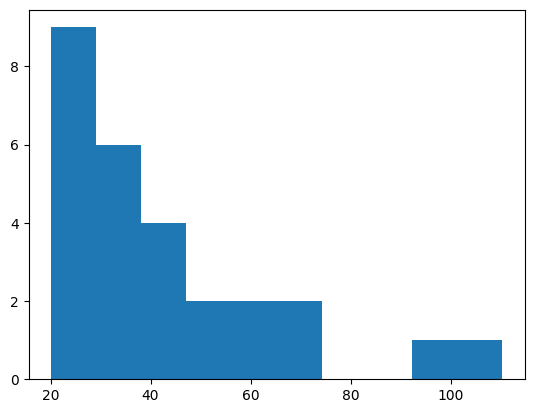

In [91]:
plt.hist(year_means)
print(np.mean(year_means), np.var(year_means, ddof=1))

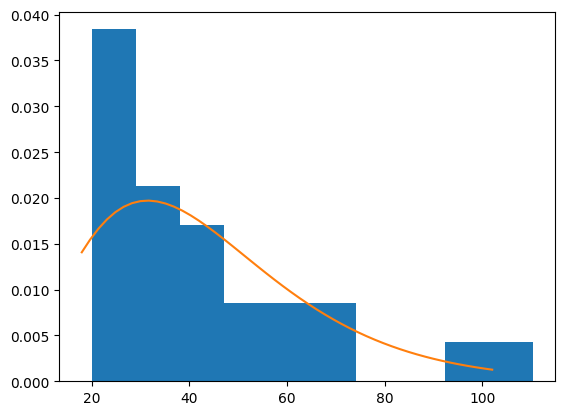

In [149]:
def find_a_and_b(mean, var):
    b = mean / var
    a = mean*b
    return a, b
a, b = find_a_and_b(np.mean(year_means[:-1]), np.var(year_means[:-1], ddof=1))
domain = np.linspace(18, 102)
plt.hist(year_means[:-1], density=True)
plt.plot(domain, stats.gamma.pdf(domain, a, scale=1/b))

In [150]:
df_2000["year"]


0       2000
1       2000
2       2000
3       2000
4       2000
        ... 
9561    2026
9562    2026
9563    2026
9564    2026
9565    2026
Name: year, Length: 9566, dtype: int64

In [157]:
year_mean_dict = {}
df_2000["year mean"] = 1
years = np.arange(2000, 2027)
for i in range(27):
    year = years[i]
    year_mean_dict[year] = year_means[i]
for i in range(len(df_2000)):
    df_2000.at[i, "year mean"] = year_mean_dict[df_2000.iloc[i]["year"]]
df_2000

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/4208175083.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '34.83753267760369' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "year mean"] = year_mean_dict[df_2000.iloc[i]["year"]]


,time,value,days,fit,fit2,fit3,day,year,year_mean,year mean,adj_value
0,2000-01-01,92.397718,434,48.990492,37.932348,37.064348,0,2000,1,34.837533,73.567046
1,2000-01-02,105.621664,435,49.482676,37.846936,36.976936,1,2000,1,34.837533,74.076749
2,2000-01-03,96.418704,436,49.973683,37.770472,36.898472,2,2000,1,34.837533,88.744851
3,2000-01-04,86.706042,437,50.463366,37.703488,36.829488,3,2000,1,34.837533,79.768426
4,2000-01-05,83.619510,438,50.951581,37.646508,36.770508,4,2000,1,34.837533,83.194758
...,...,...,...,...,...,...,...,...,...,...,...
9561,2026-03-06,79.003872,9995,70.549130,66.854177,46.864177,71,2026,1,37.215662,38.652432
9562,2026-03-07,72.932750,9996,70.792415,67.638611,47.646611,72,2026,1,37.215662,42.786685
9563,2026-03-08,70.944911,9997,71.028230,68.420987,48.426987,73,2026,1,37.215662,47.487274
9564,2026-03-09,68.897606,9998,71.256505,69.200528,49.204528,74,2026,1,37.215662,49.016381


In [159]:
df_2000["adj_value"] = df_2000["value"] / df_2000["year mean"]

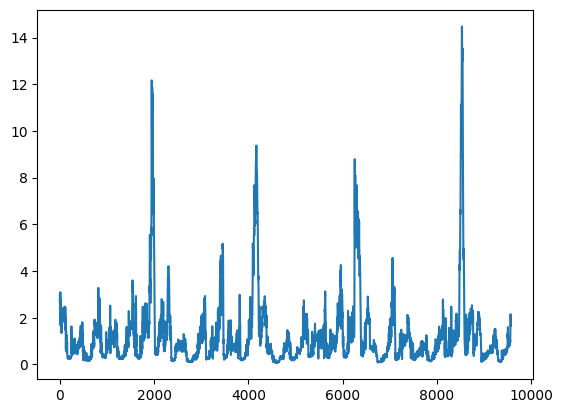

In [160]:
plt.plot(df_2000["adj_value"])

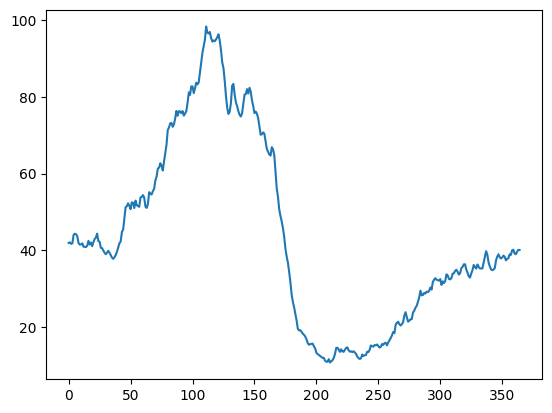

In [161]:
plt.plot(sim_df["mean"])

In [164]:
df_2000 = df_2000[['time', 'value', 'day', 'year']]

In [248]:
SPRING_START = 80
SPRING_END = 130
filtered = df_2000[df_2000["day"] >= SPRING_START]
filtered = filtered[filtered["day"] <= SPRING_END]
spring_means = filtered.groupby("year").mean()["value"].values

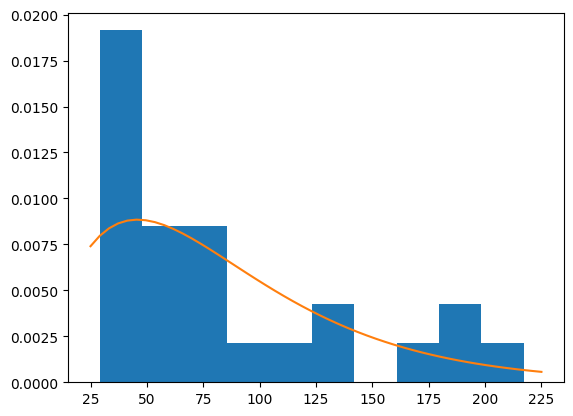

In [259]:
a, b = find_a_and_b(np.mean(spring_means[:-1]), np.var(spring_means[:-1], ddof=1))
domain = np.linspace(25, 225)
plt.hist(spring_means[:-1], density=True, bins=10)
plt.plot(domain, stats.gamma.pdf(domain, a, scale=1/b))

In [250]:
df_2000 = df_2000[df_2000["year"] <= 2025]
spring_mean_dict = {}
df_2000["spring mean"] = 1
years = np.arange(2000, 2027)
for i in range(26):
    year = years[i]
    spring_mean_dict[year] = spring_means[i]
for i in range(len(df_2000)):
    df_2000.at[i, "spring mean"] = spring_mean_dict[df_2000.iloc[i]["year"]]
df_2000["adj value"] = df_2000["value"] / df_2000["spring mean"]

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/1648123392.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '66.43010233725491' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "spring mean"] = spring_mean_dict[df_2000.iloc[i]["year"]]


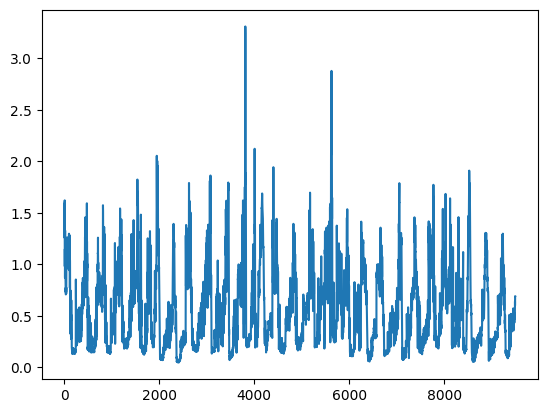

In [251]:
plt.plot(df_2000["adj value"])

In [252]:
day_adj_vals = df_2000.groupby("day").mean()["adj value"].values
day_adj_vars = df_2000[["day", "adj value"]].groupby("day").var()["adj value"].values

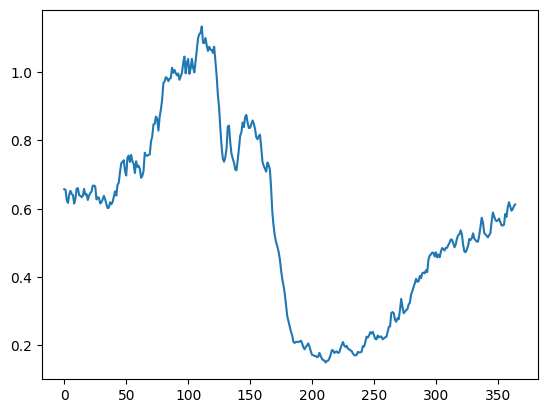

In [253]:
plt.plot(np.arange(365), day_adj_vals)

In [260]:
df_2000["error"] = 1000
df_2000["pred"] = 0
for i in range(len(df_2000)):
    pred = df_2000.iloc[i]["spring mean"] * day_adj_vals[df_2000.iloc[i]["day"]]
    df_2000.at[i, "pred"] = pred
    df_2000.at[i, "error"] = pred - df_2000.iloc[i]["value"]
df_2000["error"]

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/1710077347.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '43.63987391904462' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "pred"] = pred
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/1710077347.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-48.757844480955384' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "error"] = pred - df_2000.iloc[i]["value"]


0      -48.757844
1      -62.070224
2      -54.837411
3      -45.720824
4      -41.006903
          ...    
9492    -0.835242
9493     1.293057
9494     0.772769
9495    -2.577758
9496    -3.215197
Name: error, Length: 9497, dtype: float64

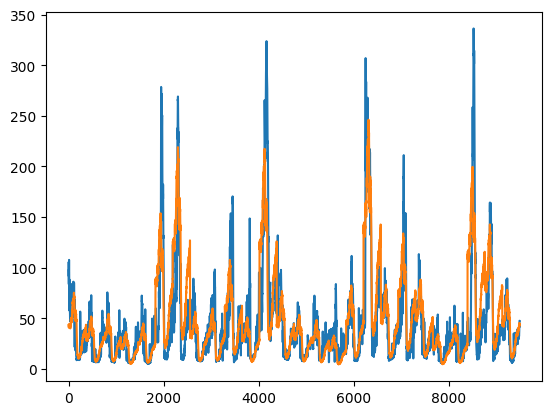

In [261]:
plt.plot(df_2000["value"])
plt.plot(df_2000["pred"])

In [247]:
df_2000["SE"] = df_2000["error"]**2
MSE = np.mean(df_2000["SE"])
print(np.sqrt(MSE))
print(np.mean(np.abs(df_2000["error"])))

28.647551871039816
16.628833523351716


0.15228989057523637

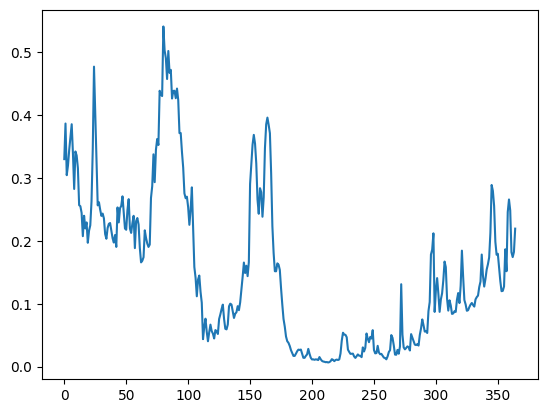

In [195]:
plt.plot(np.arange(365), day_adj_vars)
np.mean(day_adj_vars)